In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import pickle

from tqdm.keras import TqdmCallback

print("TensorFlow version:", tf.__version__)
print("Input folders:", os.listdir("/kaggle/input"))


TensorFlow version: 2.18.0
Input folders: ['imdb-dataset-of-50k-movie-reviews']


In [2]:
data_path = "/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"

df = pd.read_csv(data_path)
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print(df.shape)
print(df['sentiment'].value_counts())

(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [4]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df[['review', 'sentiment', 'label']].head()

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [5]:
X = df['review'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

len(X_train), len(X_test)

(40000, 10000)

In [6]:
MAX_VOCAB_SIZE = 20000   # số từ tối đa trong vocab
MAX_SEQ_LEN = 200        # độ dài câu tối đa (token)

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQ_LEN,
    padding='post',
    truncating='post'
)
X_test_padded = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQ_LEN,
    padding='post',
    truncating='post'
)

X_train_padded.shape, X_test_padded.shape

((40000, 200), (10000, 200))

In [7]:
EMBED_DIM = 128
LSTM_UNITS = 128

model = Sequential()
model.add(
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_SEQ_LEN
    )
)
model.add(LSTM(LSTM_UNITS, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1763556476.829605      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [13]:
BATCH_SIZE = 128
EPOCHS = 10

history = model.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,  
    callbacks=[TqdmCallback(verbose=1)]  
)

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

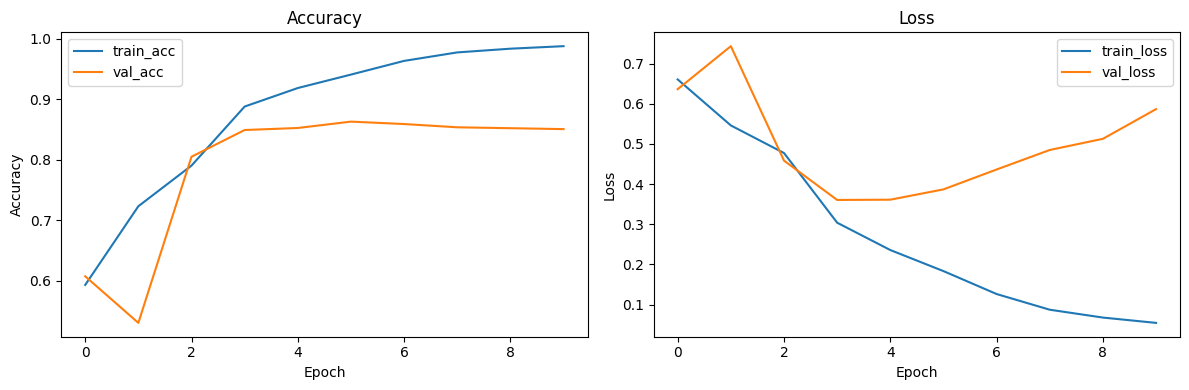

In [14]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
test_loss, test_acc = model.evaluate(X_test_padded, y_test, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.6022305488586426
Test Accuracy: 0.8525000214576721


In [16]:
y_pred_prob = model.predict(X_test_padded, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).reshape(-1)

print(classification_report(y_test, y_pred, digits=4))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0     0.8431    0.8662    0.8545      5000
           1     0.8624    0.8388    0.8505      5000

    accuracy                         0.8525     10000
   macro avg     0.8528    0.8525    0.8525     10000
weighted avg     0.8528    0.8525    0.8525     10000

[[4331  669]
 [ 806 4194]]


In [17]:
def predict_sentiment(text: str):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(
        seq,
        maxlen=MAX_SEQ_LEN,
        padding='post',
        truncating='post'
    )
    prob = model.predict(padded, verbose=0)[0][0]
    label = 1 if prob >= 0.5 else 0
    sentiment = "positive" if label == 1 else "negative"
    confidence = float(prob if label == 1 else 1 - prob)
    return {
        "text": text,
        "pred_label": label,
        "pred_sentiment": sentiment,
        "confidence": confidence
    }

print(predict_sentiment("The movie was awesome and I really enjoyed it!"))
print(predict_sentiment("The movie was boring and terrible."))

{'text': 'The movie was awesome and I really enjoyed it!', 'pred_label': 1, 'pred_sentiment': 'positive', 'confidence': 0.9886406660079956}
{'text': 'The movie was boring and terrible.', 'pred_label': 0, 'pred_sentiment': 'negative', 'confidence': 0.9955265522003174}


In [18]:
model_path = "sentiment_lstm_imdb.keras"
model.save(model_path)
print("Saved model to", os.path.abspath(model_path))

Saved model to /kaggle/working/sentiment_lstm_imdb.keras


In [19]:
tokenizer_path = "tokenizer_imdb.pkl"
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

print("Saved tokenizer to", os.path.abspath(tokenizer_path))

Saved tokenizer to /kaggle/working/tokenizer_imdb.pkl
